## Create a Regression Model
### Load_Diabetes dataset

Load up required libraries and dataset. 


In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.pipeline import make_pipeline
# Load the dataset

diabetes = load_diabetes()
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target
diabetes_df.head()




,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
print(diabetes_df.isna().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


## Checking for correlation between some features and the target value

In [3]:
print(diabetes_df['s4'].corr(diabetes_df['target']))

0.43045288474477295


In [4]:

print(diabetes_df['bmi'].corr(diabetes_df['target']))

0.5864501344746885


In [5]:
print(diabetes_df['age'].corr(diabetes_df['target']))

0.18788875071891983


In [6]:
print(diabetes_df['bp'].corr(diabetes_df['target']))

0.44148175856257094


In [7]:
X = diabetes_df[diabetes.feature_names]
y = diabetes_df['target']

## Training the model

In [8]:
# Linear regression model
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=0)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
test_pred = linear_model.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test,test_pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(test_pred)*100:3.3}%)')
score = linear_model.score(X_train,y_train)
print('Model determination: ', score)

Mean error: 58.5 (37.5%)
Model determination:  0.5539250081377072


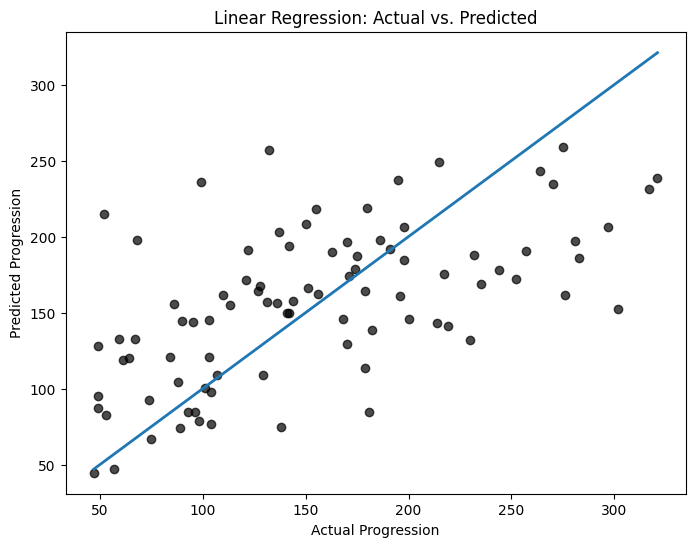

In [13]:
# Visualization: Actual vs. Predicted (for test set)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_pred, alpha=0.7, color = 'black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],  lw=2)
plt.xlabel('Actual Progression')
plt.ylabel('Predicted Progression')
plt.title('Linear Regression: Actual vs. Predicted')
plt.show()

In [10]:
#Polynomial Regression model
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

pipeline.fit(X_train,y_train)

pred = pipeline.predict(X_test)

mse = np.sqrt(mean_squared_error(y_test,pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)')

score = pipeline.score(X_train,y_train)
print('Model determination: ', score)

Mean error: 60.3 (39.0%)
Model determination:  0.6320064858939728


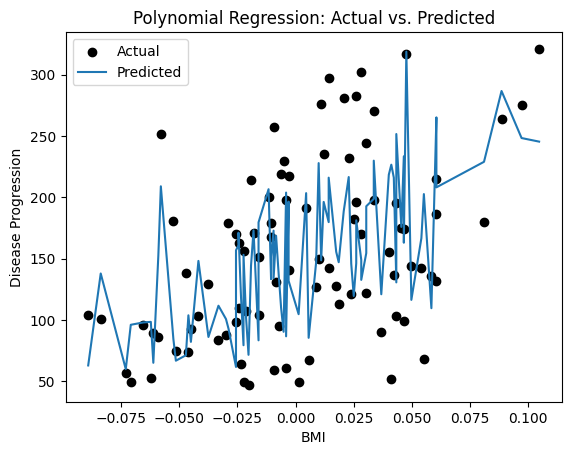

In [15]:
# Use 'bmi' as the x-axis feature
x_plot = X_test['bmi']

plt.scatter(x_plot, y_test, label='Actual',color = 'black')

# Sort for smooth line plot
sorted_idx = np.argsort(x_plot)
x_sorted = x_plot.iloc[sorted_idx]
pred_sorted = pipeline.predict(X_test.iloc[sorted_idx])

plt.plot(x_sorted, pred_sorted,  label='Predicted')

plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.title('Polynomial Regression: Actual vs. Predicted')
plt.legend()
plt.show()

### Why I chose the linear regression model
I bulit two models that is the linear regression model and polynomial regression model but in the end I chose linear regression because it produced lower prediction error(lower RMSE and lower Mean Absolute Percentage Error), even though the polynomial model shows a higher R^2 on the same data. The polynomial explains more variance but gives worse absolute errors. Also a higher R^2 doesn't guarantee lower prediction errors on new data. Also simple baseline assuming linear relationships(e.g., higher BMI increases progression) and works well with standardized features.

### If the model is not accurate: likely causes
1. Intrinsic noise: The dataset contains biological variability. Diabetes progression depends on unmodeled factors(e.g., genetics, lifestyle, diet). Medical datasets often have high variance; R^2 of 0.55 is typical for this dataset with all features.
2. Outliers: Large errors from few samples can inflate RMSE.
3. Feature Limitations: Even with all 10 features, some variance(e.g., 45% ) in the linear regression model remains unexplained due to missing predictors(e.g., genetic markers)
4. Non-Linearity: The polynomial model’s R² improvement (0.5539 → 0.6320) confirms some non-linear effects, but the small RMSE increase suggests these effects are not strong enough to justify the complexity.